# Top

In [114]:
%matplotlib inline
%load_ext autoreload
from verimon.analysis import *

experiment_dir = "../stats/exp-2025-01-13_11-33-11-compare-trad-premise-snl"
experiment_data = load_experiment_data(experiment_dir)

symbols, colors = add_symbol_color(experiment_data)

clean_data(experiment_data)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 45 JSON files from ../stats/exp-2025-01-13_11-33-11-compare-trad-premise-snl


In [115]:
import os

os.system(f"grep -r 'WARNING' {experiment_dir}/logs/*")
os.system(f"grep -r 'ERROR' {experiment_dir}/logs/*")
longest_experiment = max(experiment_data, key=lambda x: x["time"]["total"])
print(
    f"Longest experiment {longest_experiment['experiment']['name']} {longest_experiment['experiment']['variant']} took {longest_experiment['time']['total']:.2f}s ({longest_experiment['time']['total'] / 60:.2f} min ({longest_experiment['time']['total'] / (60 * 60):.2f} h))."
)

../stats/exp-2025-01-13_11-33-11-compare-trad-premise-snl/logs/2025-01-13_11-33-11-refuel-(file=refuel.nm,parameters={'constants': 'N=3,ENERGY=3'}).log:WARNING:2025-01-13 11:45:01,995 - (0.00s) - verify.py:279 - Paynt value and filtering value differ: 19/100 vs 541/1000
../stats/exp-2025-01-13_11-33-11-compare-trad-premise-snl/logs/2025-01-13_11-33-11-refuel-(file=refuel.nm,parameters={'constants': 'N=3,ENERGY=3'}).log:WARNING:2025-01-13 11:45:25,179 - (0.00s) - verify.py:279 - Paynt value and filtering value differ: 19/100 vs 541/1000
../stats/exp-2025-01-13_11-33-11-compare-trad-premise-snl/logs/2025-01-13_11-33-11-refuel-(file=refuel.nm,parameters={'constants': 'N=4,ENERGY=3'}).log:WARNING:2025-01-13 11:46:29,878 - (0.00s) - verify.py:279 - Paynt value and filtering value differ: 19/100 vs 541/1000
../stats/exp-2025-01-13_11-33-11-compare-trad-premise-snl/logs/2025-01-13_11-33-11-refuel-(file=refuel.nm,parameters={'constants': 'N=4,ENERGY=3'}).log:WARNING:2025-01-13 11:48:00,484 - (

# Compare runtimes of verimon and traditional learning

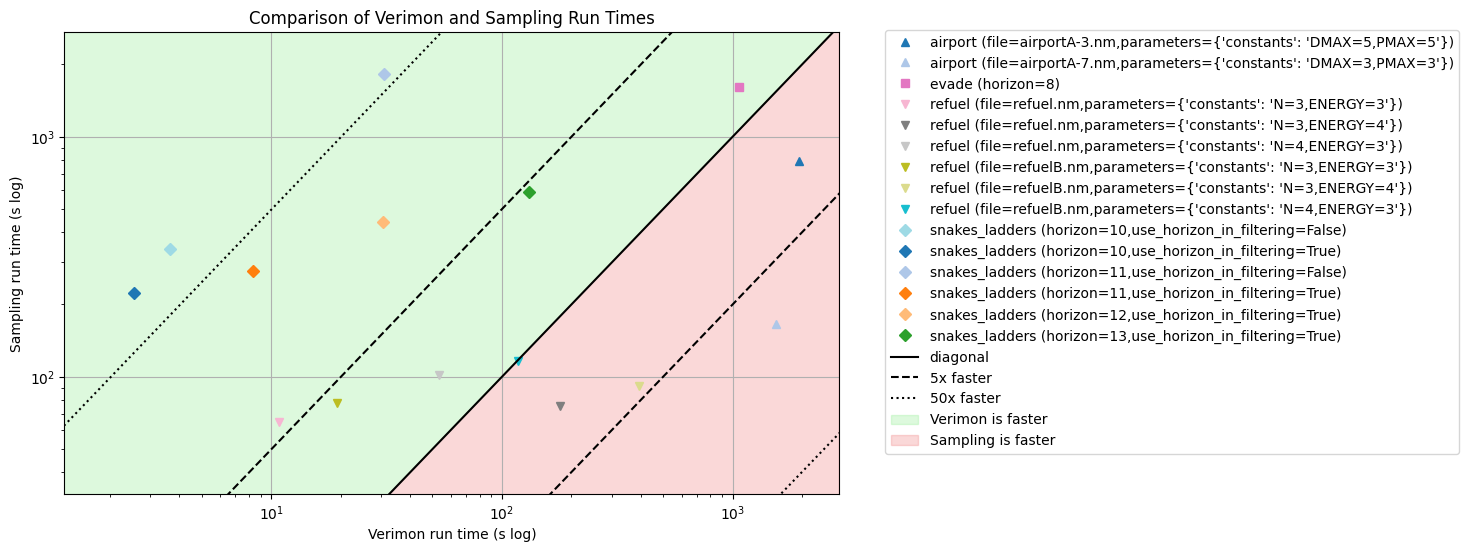

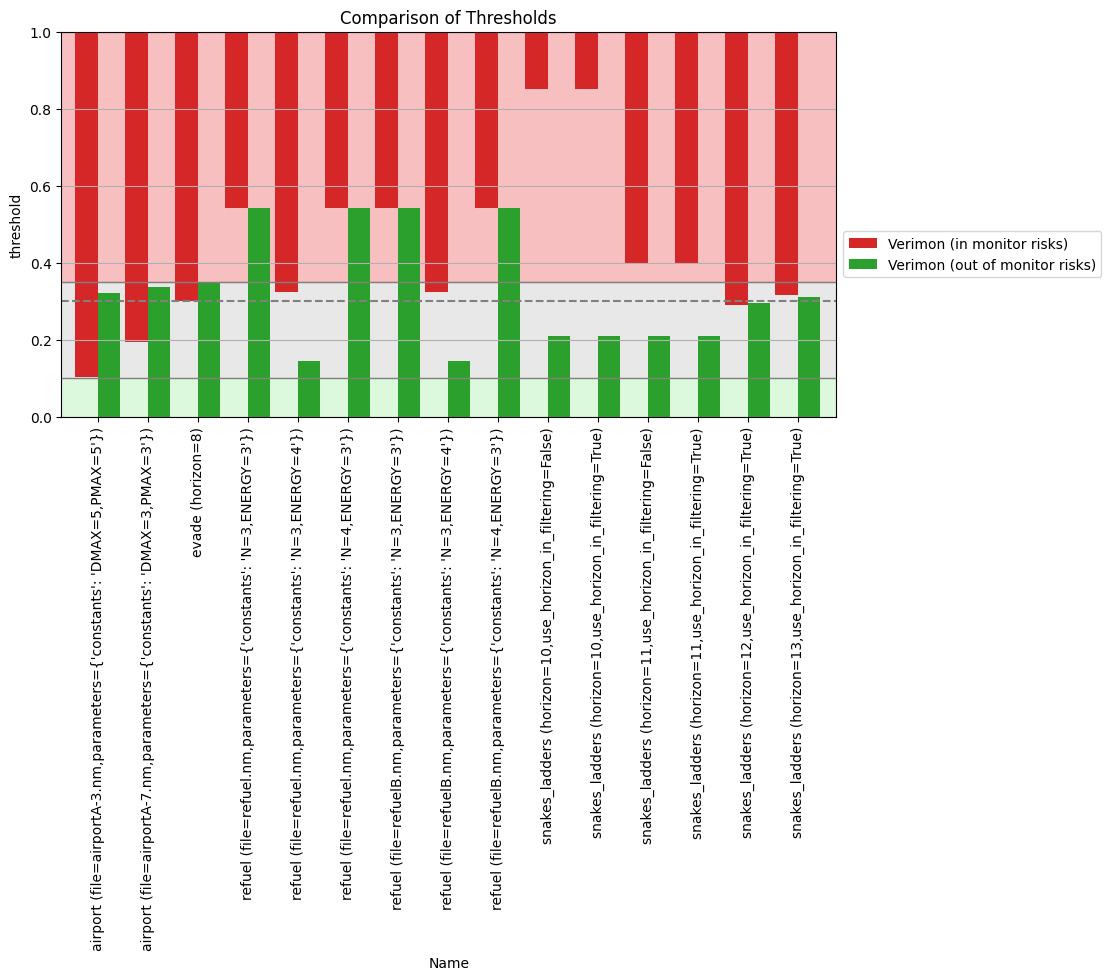

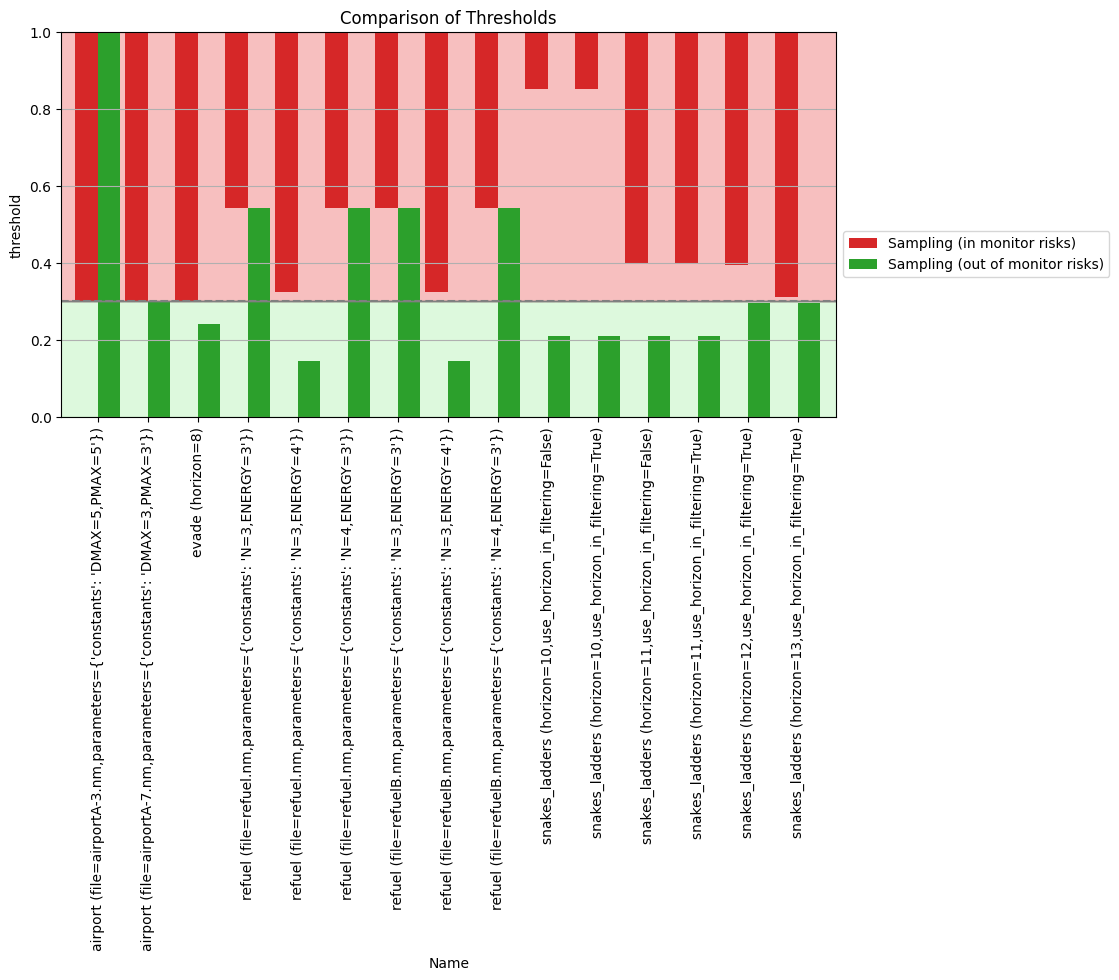

In [116]:
verimon_data = [d for d in experiment_data if "verimon" in d]
compare_runtimes(verimon_data, "verimon", "sampling")
# compare_thresholds(verimon_data, "verimon", "sampling", colors)
compare_thresholds_bar(
    verimon_data,
    ["verimon"],
    "name",
    lambda d: f"{d['experiment']['name']} {d['experiment']['variant']}",
    colors,
    0.3,
    0.05,
    0.2,
)
compare_thresholds_bar(
    verimon_data,
    ["sampling"],
    "name",
    lambda d: f"{d['experiment']['name']} {d['experiment']['variant']}",
    colors,
    0.3,
)

# Compare learned monitor sizes

/tmp/ipykernel_45634/1249483815.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


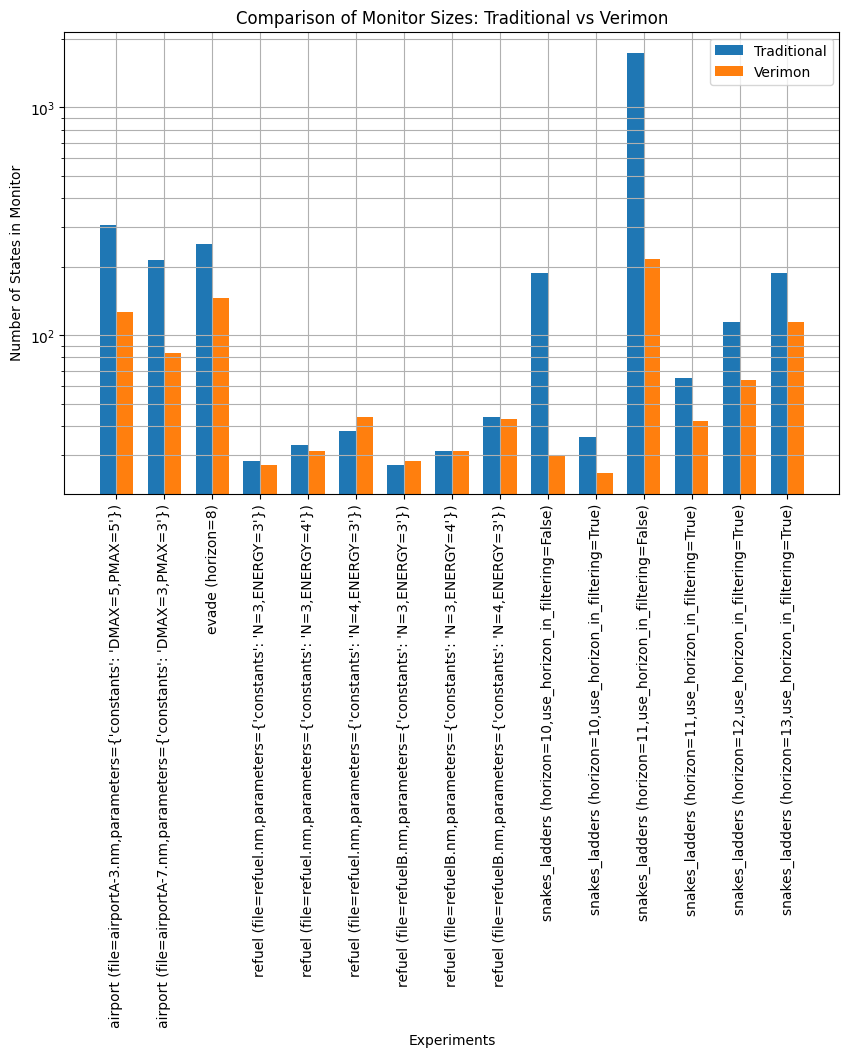

In [117]:
trad_monitor_sizes = [
    data["sampling"]["monitor_states"] for data in experiment_data if "verimon" in data
]
verimon_monitor_sizes = [
    data["verimon"]["monitor_states"] for data in experiment_data if "verimon" in data
]
experiment_names = [
    data["experiment"]["name"] + " " + str(data["experiment"]["variant"])
    for data in experiment_data
    if "verimon" in data
]

plt.figure(figsize=(10, 6))
plt.grid(which="both")
bar_width = 0.35
index = range(len([d for d in experiment_data if "verimon" in d]))

plt.bar(index, trad_monitor_sizes, bar_width, label="Traditional")
plt.bar(
    [i + bar_width for i in index], verimon_monitor_sizes, bar_width, label="Verimon"
)
plt.yscale("log")

plt.xlabel("Experiments")
plt.ylabel("Number of States in Monitor")
plt.title("Comparison of Monitor Sizes: Traditional vs Verimon")
plt.xticks([i + bar_width / 2 for i in index], experiment_names, rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

# Runtime by parameters

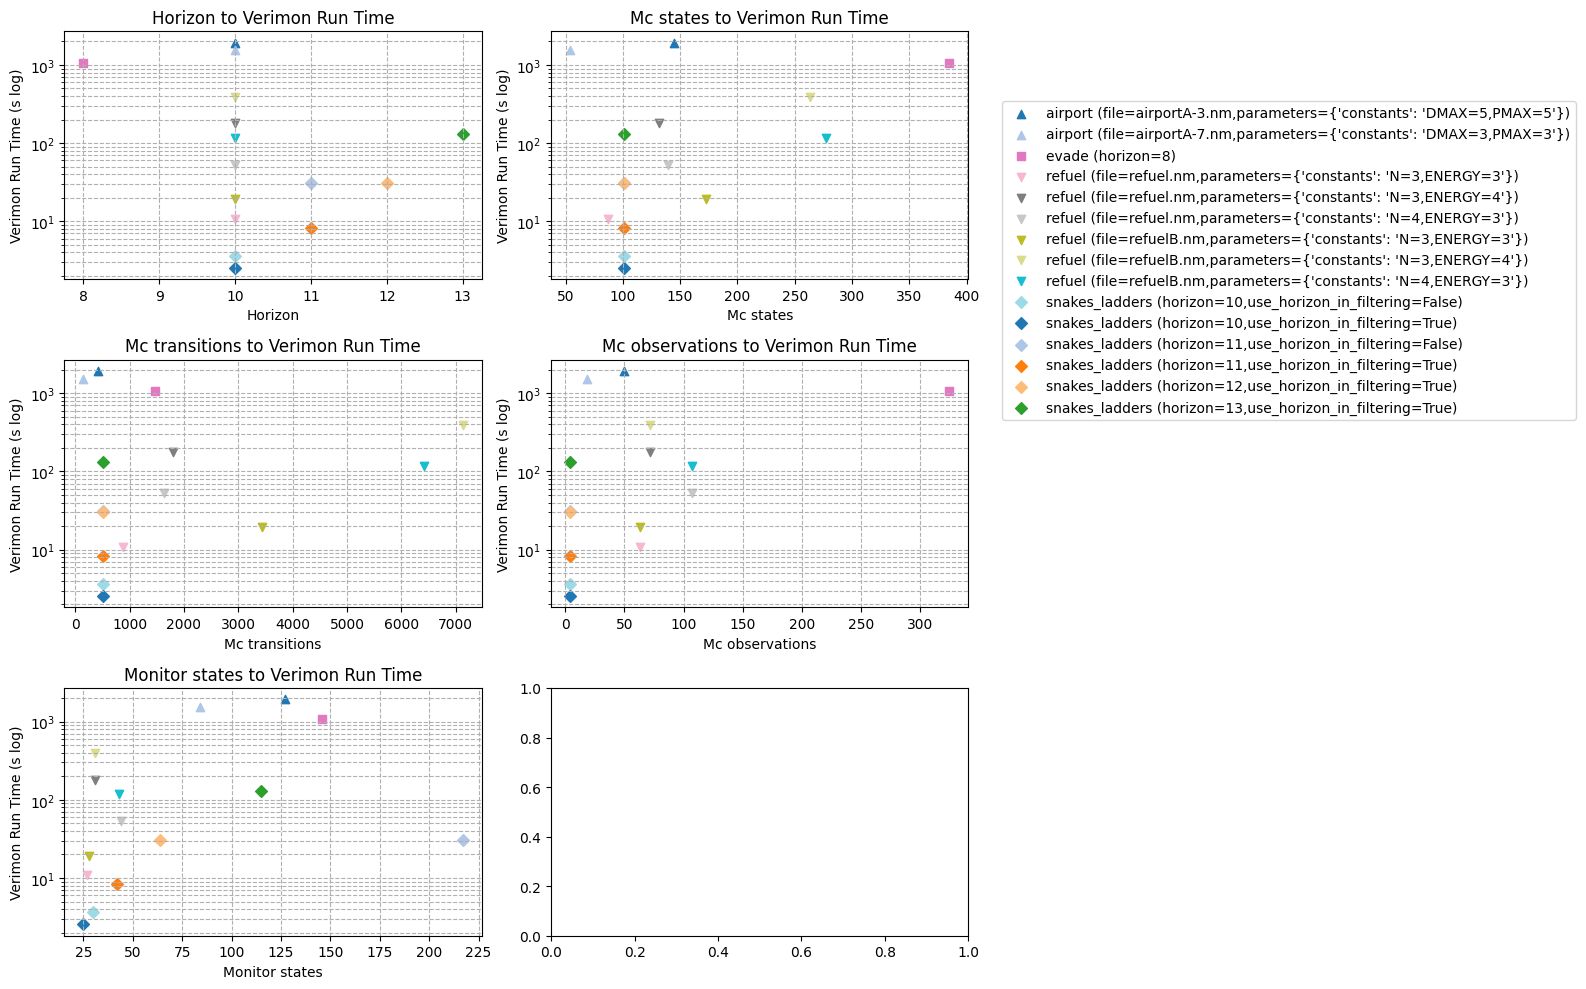

In [118]:
parameters = [
    ("experiment", "horizon"),
    ("mc", "mc_states"),
    ("mc", "mc_transitions"),
    ("mc", "mc_observations"),
    ("verimon", "monitor_states"),
]

runtime_by_params(
    [data for data in experiment_data if "verimon" in data], "verimon", parameters
)

# Compare horizon on and off in snakes and ladders data

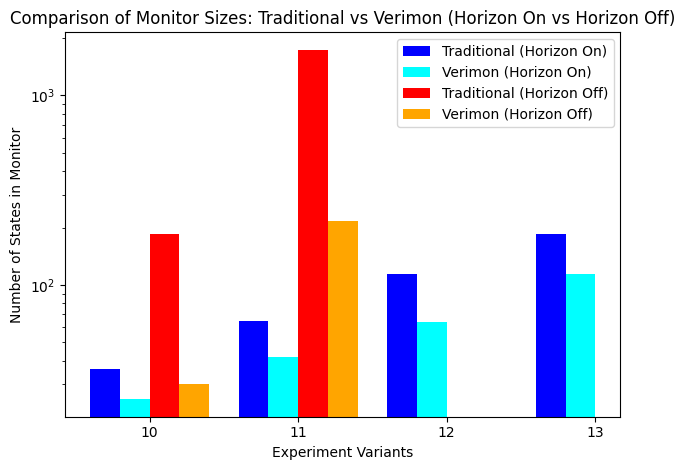

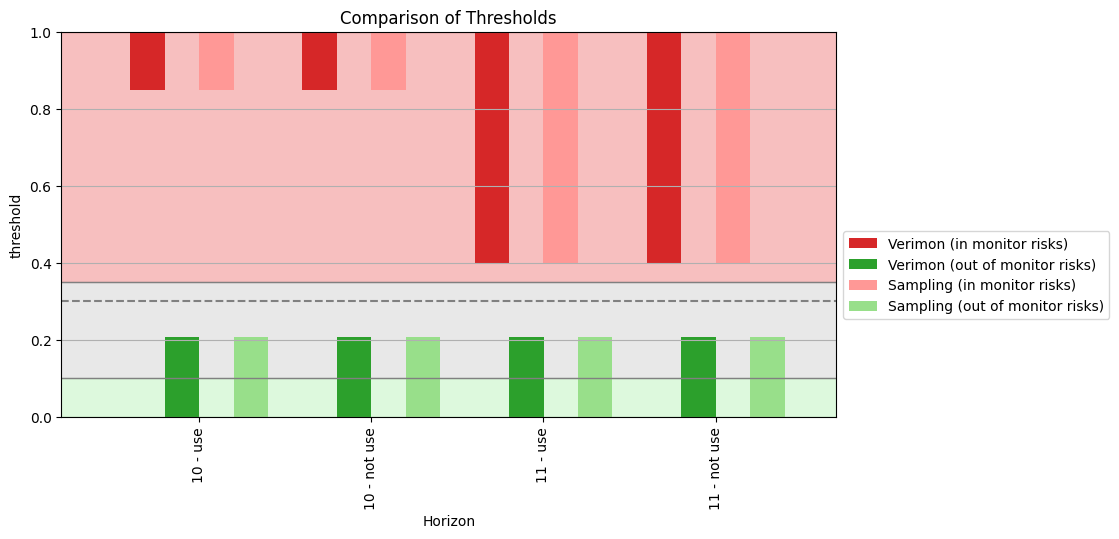

In [119]:
# Filter data for snakes and ladders experiments
snakes_ladders_data = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "snakes_ladders"
    ],
    key=lambda x: x["experiment"]["horizon"],
)

# Separate data based on use_horizon_in_filtering
horizon_on_data = [
    data
    for data in snakes_ladders_data
    if data["experiment"]["use_horizon_in_filtering"]
]
horizon_off_data = [
    data
    for data in snakes_ladders_data
    if not data["experiment"]["use_horizon_in_filtering"]
]

# Extract monitor sizes
horizon_on_trad_sizes = [data["sampling"]["monitor_states"] for data in horizon_on_data]
horizon_on_verimon_sizes = [
    data["verimon"]["monitor_states"] for data in horizon_on_data
]
horizon_off_trad_sizes = [
    data["sampling"]["monitor_states"] for data in horizon_off_data
]
horizon_off_verimon_sizes = [
    data["verimon"]["monitor_states"] for data in horizon_off_data
]

# Horizon sizes for x-axis labels
horizon_on_names = [data["experiment"]["horizon"] for data in horizon_on_data]
horizon_off_names = [data["experiment"]["horizon"] for data in horizon_off_data]

bar_width = 1 / 4 - 0.05
index_on = range(len(horizon_on_data))
index_off = range(len(horizon_off_data))

# Plot for use_horizon_in_filtering = True
plt.bar(
    index_on,
    horizon_on_trad_sizes,
    bar_width,
    label="Traditional (Horizon On)",
    color="blue",
)
plt.bar(
    [i + bar_width for i in index_on],
    horizon_on_verimon_sizes,
    bar_width,
    label="Verimon (Horizon On)",
    color="cyan",
)

# Plot for use_horizon_in_filtering = False
plt.bar(
    [i + 2 * bar_width for i in index_off],
    horizon_off_trad_sizes,
    bar_width,
    label="Traditional (Horizon Off)",
    color="red",
)
plt.bar(
    [i + 3 * bar_width for i in index_off],
    horizon_off_verimon_sizes,
    bar_width,
    label="Verimon (Horizon Off)",
    color="orange",
)

plt.xlabel("Experiment Variants")
plt.ylabel("Number of States in Monitor")
plt.title(
    "Comparison of Monitor Sizes: Traditional vs Verimon (Horizon On vs Horizon Off)"
)
plt.xticks(
    [i + bar_width * 3 / 2 for i in index_on],
    horizon_on_names,
)
plt.legend()
plt.yscale("log")

plt.tight_layout()
plt.show()

# Plot for use_horizon_in_filtering = True
# Interleave horizon on and off data
interleaved_data = []
for on, off in zip(horizon_on_data, horizon_off_data):
    interleaved_data.append(on)
    interleaved_data.append(off)

compare_thresholds_bar(
    interleaved_data,
    ["verimon", "sampling"],
    "horizon",
    lambda d: f"{d['experiment']['horizon']} - {'use' if d['experiment']['use_horizon_in_filtering'] else 'not use'}",
    colors,
    0.3,
    0.05,
    0.2,
)

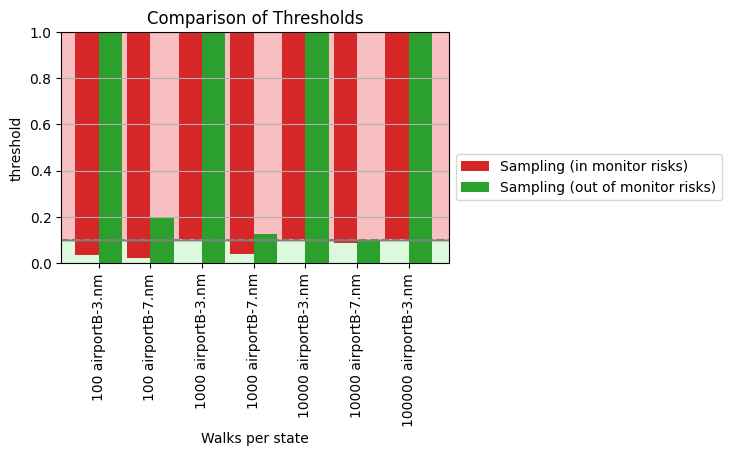

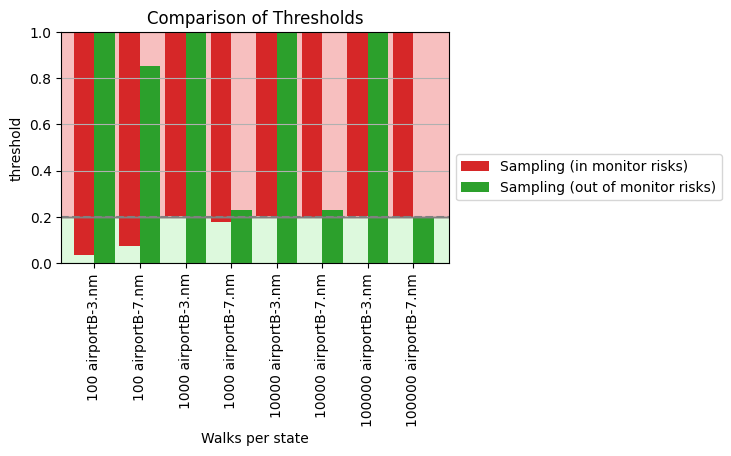

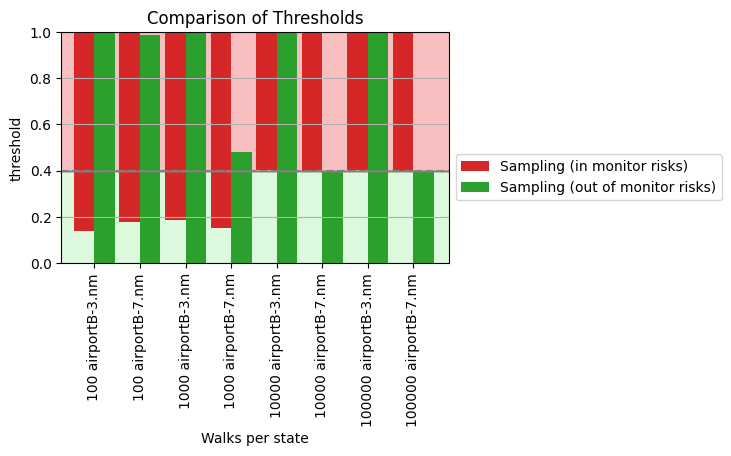

In [120]:
compare_trad_data_low_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.1
            or data["experiment"]["threshold"] == Fraction(1, 10)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)
compare_trad_data_mid_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.2
            or data["experiment"]["threshold"] == Fraction(1, 5)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)
compare_trad_data_high_threshold = sorted(
    [
        data
        for data in experiment_data
        if data["experiment"]["name"] == "compare-trad"
        and (
            data["experiment"]["threshold"] == 0.4
            or data["experiment"]["threshold"] == Fraction(2, 5)
        )
    ],
    key=lambda x: (x["experiment"]["old_walks_per_state"], x["experiment"]["file"]),
)

compare_thresholds_bar(
    compare_trad_data_low_threshold,
    ["sampling"],
    "walks per state",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['file'].split('/')[-1]}",
    colors,
    threshold=0.1,
    fig_size=(5, 3),
)
compare_thresholds_bar(
    compare_trad_data_mid_threshold,
    ["sampling"],
    "walks per state",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['file'].split('/')[-1]}",
    colors,
    threshold=0.2,
    fig_size=(5, 3),
)
compare_thresholds_bar(
    compare_trad_data_high_threshold,
    ["sampling"],
    "walks per state",
    lambda d: f"{d['experiment']['old_walks_per_state']} {d['experiment']['file'].split('/')[-1]}",
    colors,
    threshold=0.4,
    fig_size=(5, 3),
)

# Relative time spent in paynt, product generator and other

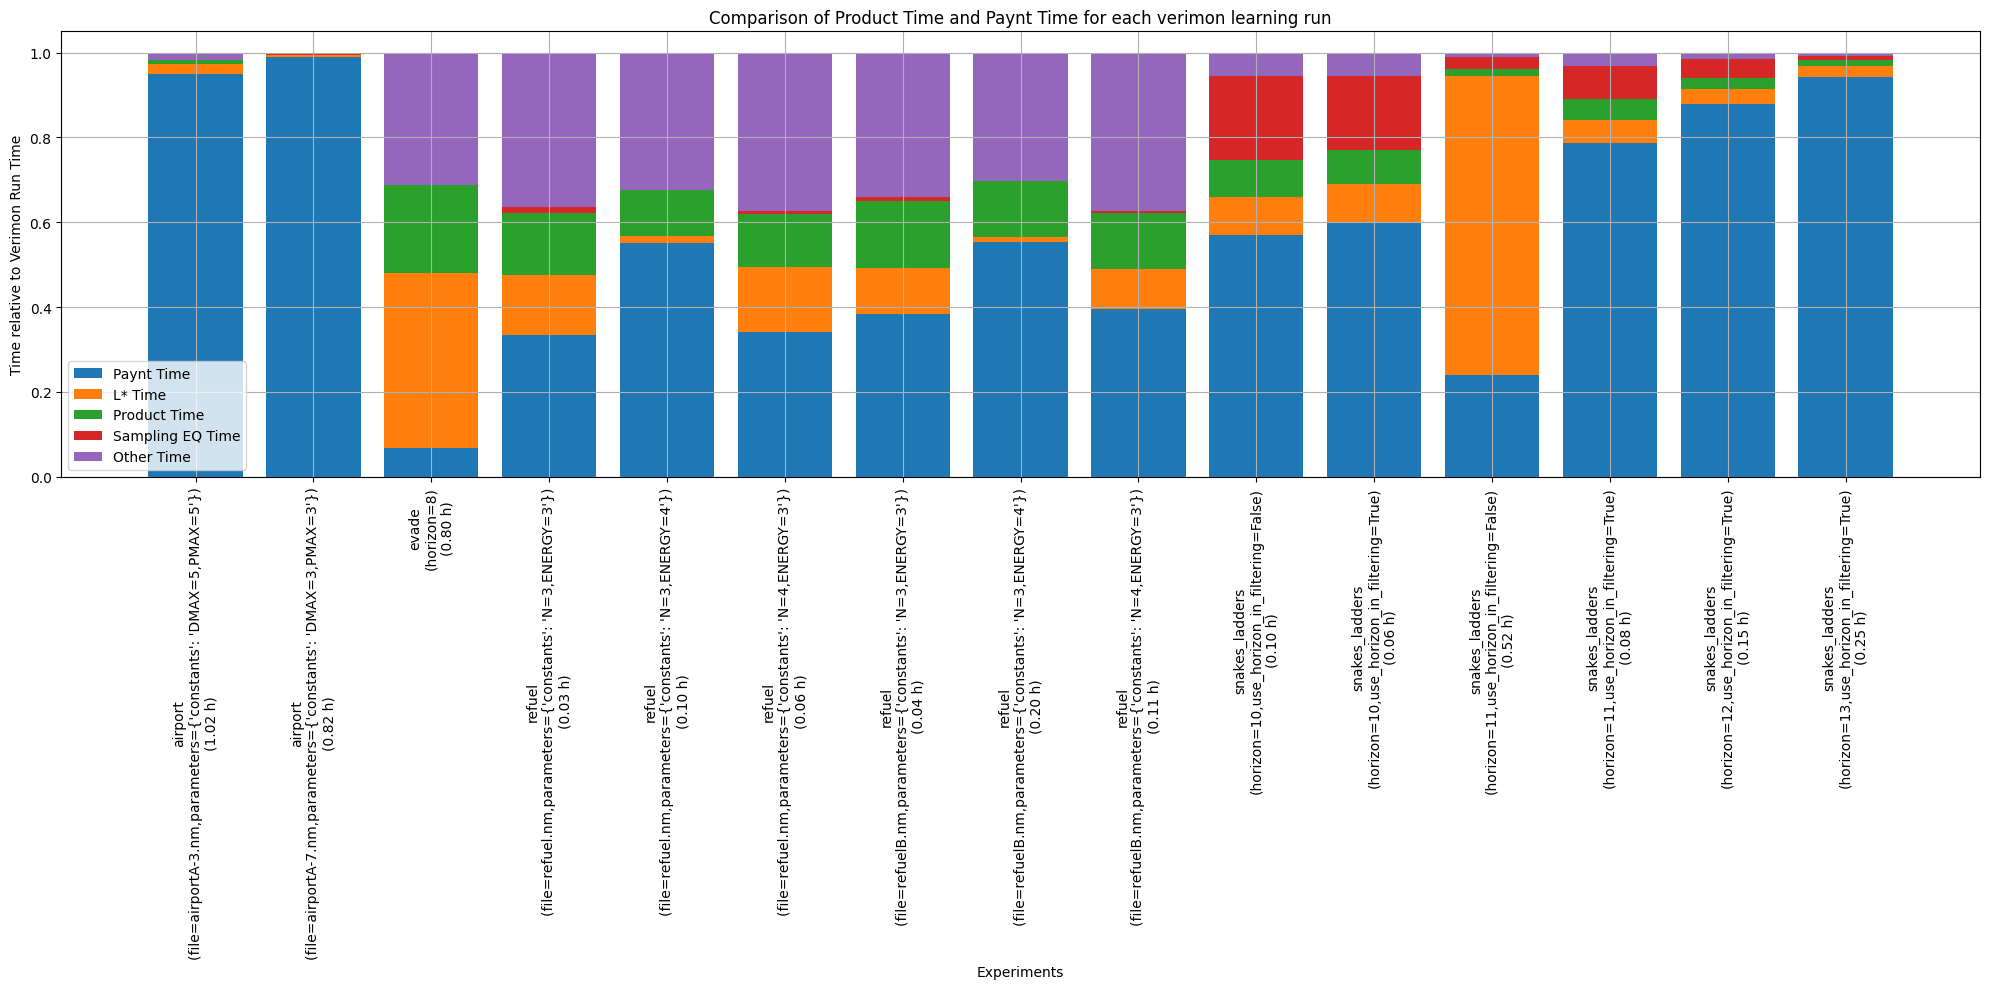

In [121]:
import numpy as np


filtered_data = [
    data for data in experiment_data if data["experiment"]["name"] != "compare-trad"
]
product_times = [
    (
        data["verimon"]["product_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
paynt_times = [
    (
        data["verimon"]["paynt_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
eq_times = [
    (
        data["verimon"]["eq_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
lstar_times = [
    (
        data["verimon"]["lstar_time"] / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]
other_times = [
    (
        1
        - (
            data["verimon"]["product_time"]
            + data["verimon"]["paynt_time"]
            + data["verimon"]["eq_time"]
            + data["verimon"]["lstar_time"]
        )
        / data["verimon"]["time"]
        if "verimon" in data and "product_time" in data["verimon"]
        else 0
    )
    for data in filtered_data
]

experiment_names = [
    f"{data['experiment']['name']}\n{data['experiment']['variant']}\n({data['time']['total']/(60*60):.2f} h)"
    for data in filtered_data
]

plt.figure(figsize=(20, 10))
index = range(len(filtered_data))
bottom = np.zeros(len(filtered_data))


plt.bar(index, paynt_times, label="Paynt Time")
bottom += paynt_times
plt.bar(index, lstar_times, bottom=bottom, label="L* Time")
bottom += lstar_times
plt.bar(index, product_times, bottom=bottom, label="Product Time")
bottom += product_times
plt.bar(
    index,
    eq_times,
    bottom=bottom,
    label="Sampling EQ Time",
)
bottom += eq_times
plt.bar(
    index,
    other_times,
    bottom=bottom,
    label="Other Time",
)

plt.xlabel("Experiments")
plt.ylabel("Time relative to Verimon Run Time")
plt.title("Comparison of Product Time and Paynt Time for each verimon learning run")
plt.xticks(index, experiment_names, rotation=90)
plt.legend()

plt.tight_layout()
plt.grid()
plt.show()